# 🏏 ICC Cricket World Cup 2023 - Analysis
Upgraded version with deeper insights, feature engineering, and strategic analysis.

# Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

## Data Loading

In [3]:
batting = pd.read_csv(r'D:\Project 5_ ICC Cricket World Cup 2023 Analysis-20260314T161342Z-1-001\batting_summary.csv')
bowling = pd.read_csv(r'D:\Project 5_ ICC Cricket World Cup 2023 Analysis-20260314T161342Z-1-001\bowling_summary.csv')
matches = pd.read_csv(r'D:\Project 5_ ICC Cricket World Cup 2023 Analysis-20260314T161342Z-1-001\match_schedule_results.csv')
players = pd.read_csv(r'D:\Project 5_ ICC Cricket World Cup 2023 Analysis-20260314T161342Z-1-001\world_cup_players_info.csv')

## Data Preprocessing and Cleaning

### Column Name Standardization

In [4]:
for df in [batting, bowling, matches, players]:
    df.columns = df.columns.str.lower().str.strip()

# fill numeric columns only to avoid filling string columns with int 0 (which raises the TypeError)
for df in [batting, bowling]:
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(0)

### Column Renaming for Consistency

In [5]:
# Batting data column renaming
batting.rename(columns={
    'match_no': 'match_id',
    'batsman_name': 'batsman',
    'team_innings': 'team',
    'dismissal': 'out_or_not_out',
    'batting_position': 'position'
}, inplace=True)

# Bowling data column renaming
bowling.rename(columns={
    'match_no': 'match_id',
    'bowler_name': 'bowler',
    'bowling_team': 'team'
}, inplace=True)

# Matches data column renaming
matches.rename(columns={
    'match_no': 'match_id',
    'date': 'date',
    'venue': 'venue',
    'team1': 'team_1',
    'team2': 'team_2',
    'winner': 'winner'
}, inplace=True)

# Players info column renaming
players.rename(columns={
    'player_name': 'player_name',
    'team_name': 'country',
    'playingrole': 'role'
}, inplace=True)

### Data Cleaning and Text Processing

In [6]:
# Remove extra spaces from team names in matches data
matches['team_1'] = matches['team_1'].str.strip()
matches['team_2'] = matches['team_2'].str.strip()
matches['winner'] = matches['winner'].str.strip()

# Create standardized dismissal status for batting data
# If dismissal is NaN, empty, or contains 'not out', then 'not out', otherwise 'out'
batting['out_or_not_out'] = batting['out_or_not_out'].apply(
    lambda x: 'not out' if (pd.isna(x) or str(x).strip() == '' or 'not out' in str(x).lower()) else 'out'
)

# Clean player names (remove extra spaces)
batting['batsman'] = batting['batsman'].str.strip()
bowling['bowler'] = bowling['bowler'].str.strip()
players['player_name'] = players['player_name'].str.strip()
batting[['team1', 'team2']] = batting['match_between'].str.split(' vs ', expand=True)

batting['batting_team'] = batting.apply(
    lambda x: x['team1'] if x['team'] == 1 else x['team2'],
    axis=1
)

### Data Integration and Merging

In [7]:
# Merge batting data with player info to get team/country information
batting = pd.merge(
    batting,
    players[['player_name', 'country', 'role']],
    left_on='batsman',
    right_on='player_name',
    how='left'
)
batting.rename(columns={'country': 'batsman_country', 'role': 'batsman_role'}, inplace=True)
batting.drop(columns=['player_name'], inplace=True)

batting = batting.merge(
    matches[['match_id', 'winner']],
    on='match_id',
    how='left'
)

batting = batting.merge(
    players[['player_name', 'role']],
    left_on='batsman',
    right_on='player_name',
    how='left'
)

# Merge bowling data with player info to get team/country information
bowling = pd.merge(
    bowling,
    players[['player_name', 'country', 'role']],
    left_on='bowler',
    right_on='player_name',
    how='left'
)
bowling.rename(columns={'country': 'bowler_country', 'role': 'bowler_role'}, inplace=True)
bowling.drop(columns=['player_name'], inplace=True)

# Check for any missing team information
batting_missing = batting['batsman_country'].isna().sum()
bowling_missing = bowling['bowler_country'].isna().sum()


if batting_missing > 0 or bowling_missing > 0:
    print(f"Warning: {batting_missing} batting records and {bowling_missing} bowling records missing team info")
else:
    print("All players successfully matched with team information")

All players successfully matched with team information


### Numeric Data Type Conversion

In [8]:
# Convert batting statistics to appropriate numeric data types

numeric_cols_batting = ['runs', 'balls', '4s', '6s', 'strike_rate']

for col in numeric_cols_batting:
    if col in batting.columns:
        batting[col] = pd.to_numeric(batting[col], errors='coerce')

# Rename boundary columns for consistency
batting.rename(columns={'4s': 'fours', '6s': 'sixes'}, inplace=True)

In [9]:
# Convert bowling statistics to appropriate numeric data types

numeric_cols_bowling = ['overs', 'maidens', 'runs', 'wickets', 'economy']

for col in numeric_cols_bowling:
    if col in bowling.columns:
        bowling[col] = pd.to_numeric(bowling[col], errors='coerce')

### Date Processing and Innings Assignment

In [10]:
# Convert 'date' column in matches_df to datetime
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')

# Add innings information to batting data based on team batting order
# Assumption: Team_1 bats first (innings 1), Team_2 bats second (innings 2)
batting = pd.merge(batting, matches[['match_id', 'team_1', 'team_2']], on='match_id', how='left')

def get_innings(row):
    if row['team'] == row['team_1']:
        return 1
    elif row['team'] == row['team_2']:
        return 2
    else:
        return 1  # default

batting['innings'] = batting.apply(get_innings, axis=1)
batting.drop(columns=['team_1', 'team_2'], inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_54820\3531040218.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  matches['date'] = pd.to_datetime(matches['date'], errors='coerce')


In [11]:
batting['strike_rate_calc'] = (batting['runs'] / batting['balls']) * 100
bowling['bowling_avg'] = bowling['runs'] / bowling['wickets'].replace(0, np.nan)

batting['50s'] = batting['runs'].apply(lambda x: 1 if 50 <= x < 100 else 0)
batting['100s'] = batting['runs'].apply(lambda x: 1 if x >= 100 else 0)

## 🔥 Top Performers Analysis

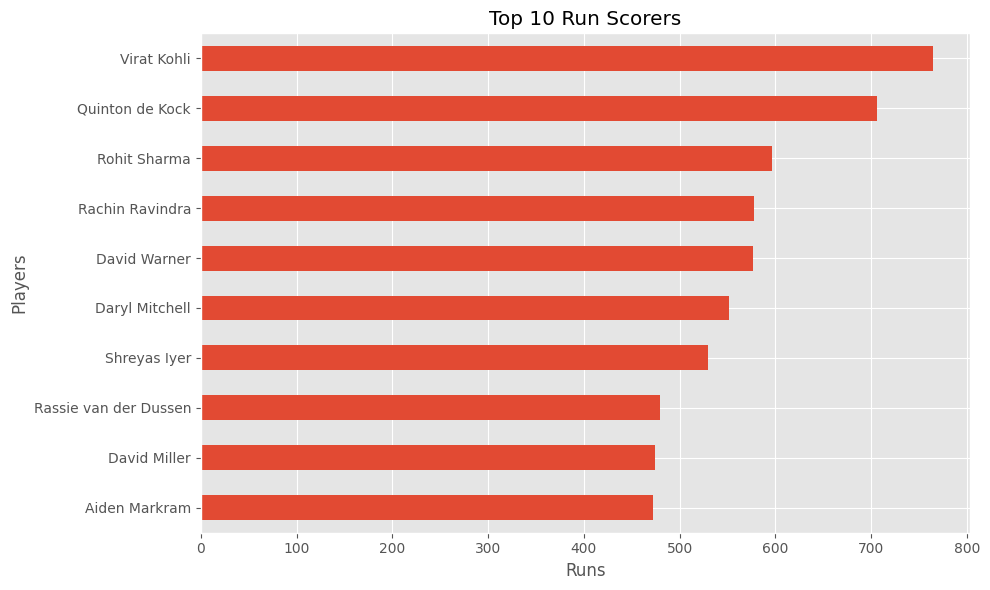

In [12]:
top_batsmen = batting.groupby('batsman')['runs'].sum().sort_values().tail(10)

plt.figure(figsize=(10,6))
top_batsmen.plot(kind='barh')

plt.title("Top 10 Run Scorers")
plt.xlabel("Runs")
plt.ylabel("Players")

plt.tight_layout()
plt.show()

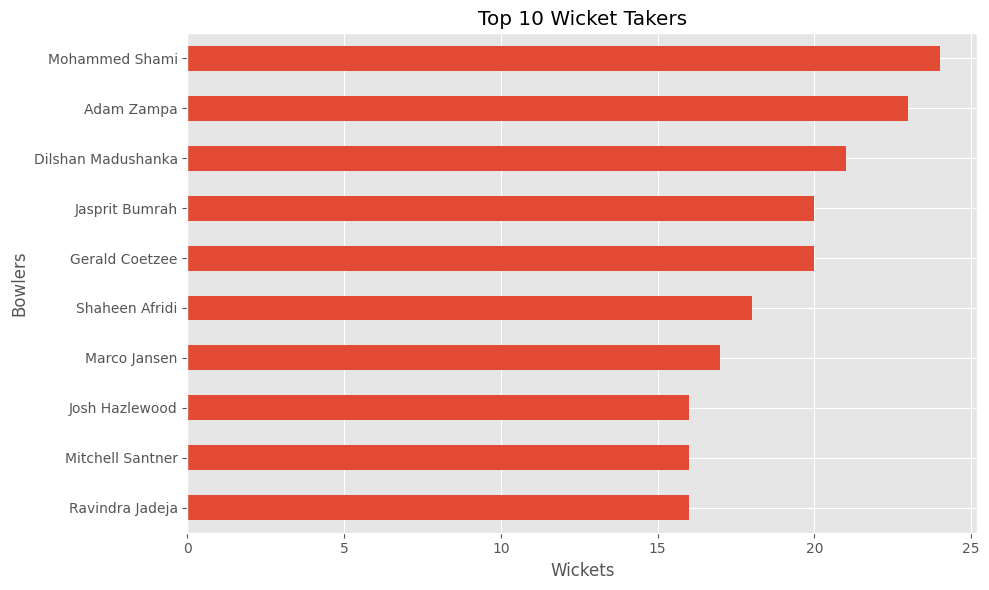

In [13]:
top_bowlers = bowling.groupby('bowler')['wickets'].sum().sort_values().tail(10)

plt.figure(figsize=(10,6))
top_bowlers.plot(kind='barh')

plt.title("Top 10 Wicket Takers")
plt.xlabel("Wickets")
plt.ylabel("Bowlers")

plt.tight_layout()
plt.show()

## ⭐ Impact Player Index (New Insight)

In [14]:
impact = batting.groupby('batsman').agg({'runs':'sum','strike_rate_calc':'mean'})
impact['impact_score'] = impact['runs'] * impact['strike_rate_calc'] / 100
impact.sort_values(by='impact_score', ascending=False).head(10)

,runs,strike_rate_calc,impact_score
batsman,,,
Rohit Sharma,597,127.900948,763.568660
Quinton de Kock,706,99.141535,699.939237
David Warner,577,117.279270,676.701386
Aiden Markram,472,141.046718,665.740508
Virat Kohli,765,83.211308,636.566508
Daryl Mitchell,552,105.546620,582.617344
David Miller,474,120.946309,573.285507
Rachin Ravindra,578,94.571246,546.621803
Heinrich Klaasen,449,119.775657,537.792700


## 🏆 Team Strength Analysis

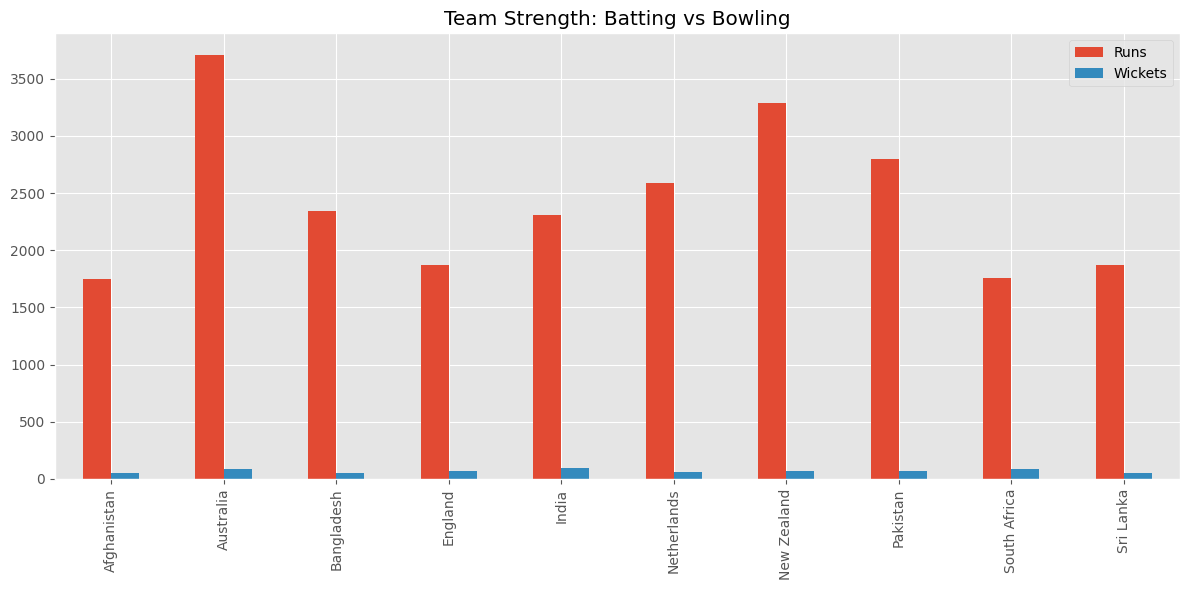

In [31]:
team_runs = batting.groupby('batting_team')['runs'].sum()
team_wickets = bowling.groupby('team')['wickets'].sum()

combined = pd.DataFrame({
    'Runs': team_runs,
    'Wickets': team_wickets
})

combined.plot(kind='bar', figsize=(12,6))

plt.title("Team Strength: Batting vs Bowling")

plt.tight_layout()
plt.show()

## 🧠 Pressure Performance Analysis

In [17]:
high_pressure = batting[batting['runs'] > 50]
pressure_players = high_pressure.groupby('batsman')['runs'].count().sort_values(ascending=False).head(10)
pressure_players

batsman
Virat Kohli          9
Quinton de Kock      5
Aiden Markram        5
Rachin Ravindra      5
Shreyas Iyer         5
Pathum Nissanka      4
Abdullah Shafique    4
Daryl Mitchell       4
David Warner         4
Travis Head          4
Name: runs, dtype: int64

## 🧠 Role Contribution

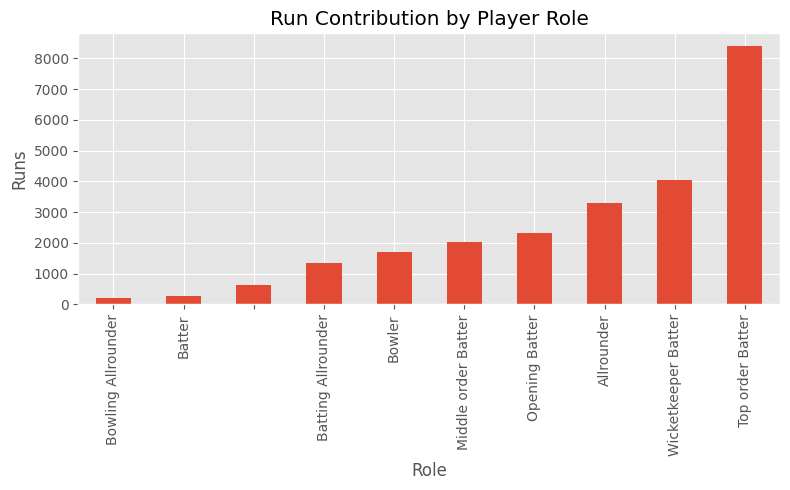

In [29]:
role_runs = batting.groupby('batsman_role')['runs'].sum().sort_values()

plt.figure(figsize=(8,5))
role_runs.plot(kind='bar')

plt.title("Run Contribution by Player Role")
plt.xlabel("Role")
plt.ylabel("Runs")

plt.tight_layout()
plt.show()

## 🏆 Winning Contribution

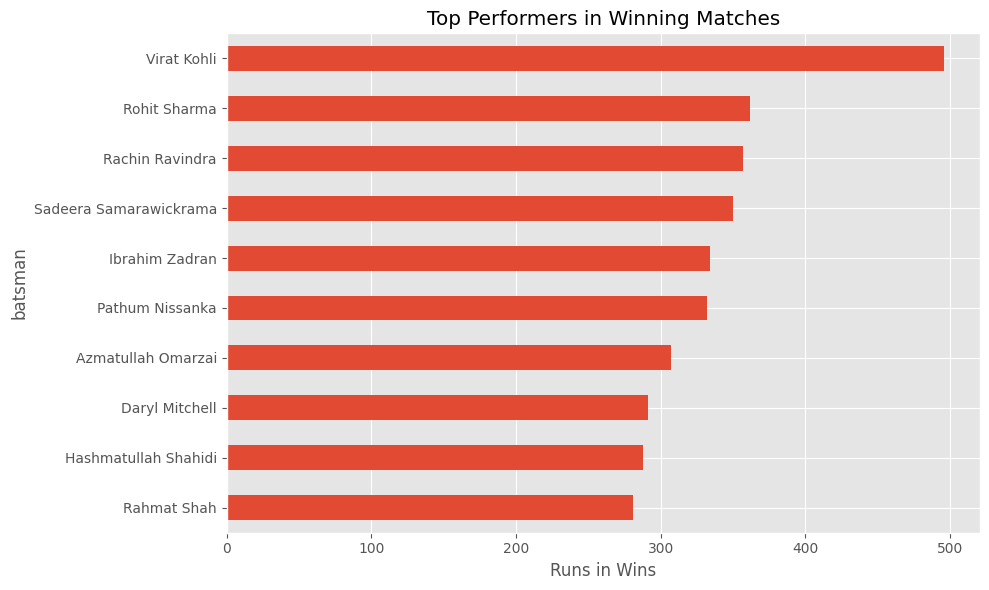

In [27]:
win_players = batting[batting['batting_team'] == batting['winner']]

top_win_players = win_players.groupby('batsman')['runs'].sum().sort_values().tail(10)

plt.figure(figsize=(10,6))
top_win_players.plot(kind='barh')

plt.title("Top Performers in Winning Matches")
plt.xlabel("Runs in Wins")

plt.tight_layout()
plt.show()

## 🧬 Team Dependency

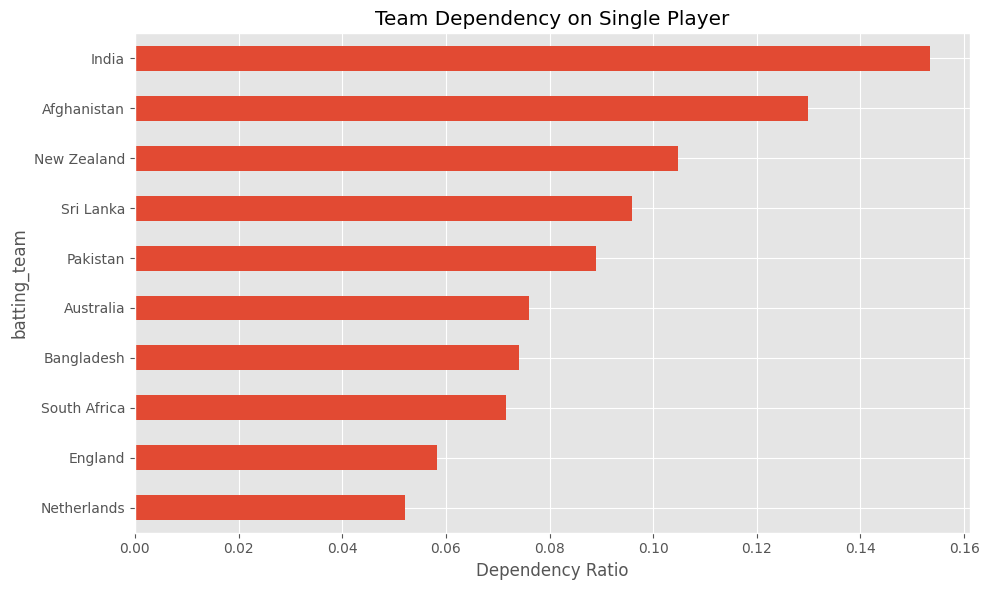

In [20]:
dep = batting.groupby(['batting_team','batsman'])['runs'].sum()
dep = dep.groupby(level=0).apply(lambda x: x/x.sum())

dependency = dep.groupby('batting_team').max().sort_values()

plt.figure(figsize=(10,6))
dependency.plot(kind='barh')

plt.title("Team Dependency on Single Player")
plt.xlabel("Dependency Ratio")

plt.tight_layout()
plt.show()

## 🏟 Advanced Venue Analysis

In [21]:
venue_scores = batting.groupby(['match_id'])['runs'].sum()
matches['total_runs'] = venue_scores.values
matches.groupby('venue')['total_runs'].mean().sort_values(ascending=False)


venue
Hyderabad                                                   550.00
Mumbai                                                      549.80
Delhi                                                       539.60
Himachal Pradesh Cricket Association Stadium, Dharamsala    527.00
Kolkata                                                     508.60
Pune                                                        508.60
Dharamsala                                                  505.75
Bengaluru                                                   494.80
Ekana Cricket Stadium Lucknow                               481.60
Ahmedabad                                                   472.20
Chennai                                                     461.60
Name: total_runs, dtype: float64

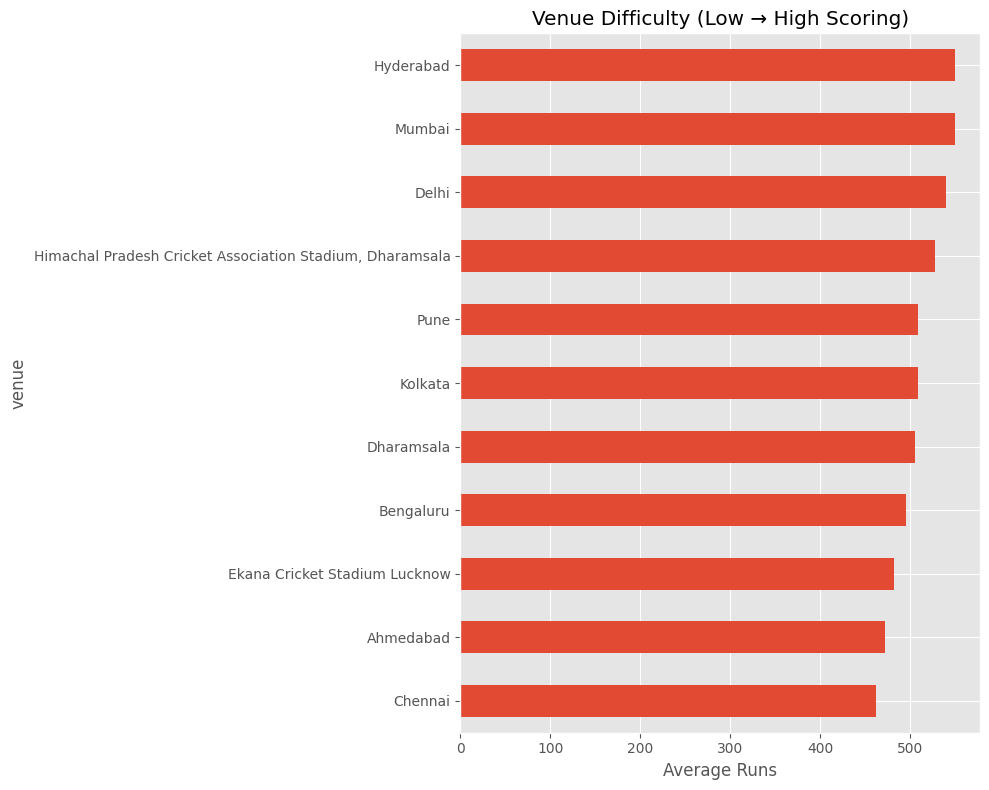

In [28]:
venue_avg_runs = matches.groupby('venue')['total_runs'].mean().sort_values()

plt.figure(figsize=(10,8))
venue_avg_runs.plot(kind='barh')

plt.title("Venue Difficulty (Low → High Scoring)")
plt.xlabel("Average Runs")

plt.tight_layout()
plt.show()

## 🪙 Toss Impact Analysis

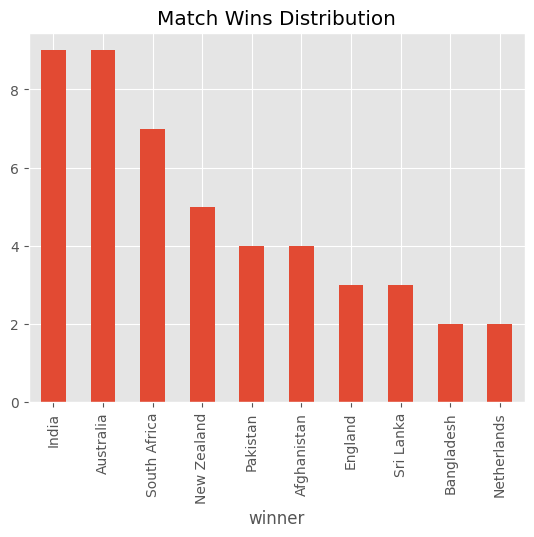

In [23]:
toss_analysis = matches['winner'].value_counts()
toss_analysis.plot(kind='bar', title='Match Wins Distribution')
plt.show()

## 📊 Player Consistency

In [24]:
consistency = batting.groupby('batsman')['runs'].std().sort_values()
consistency.head(10)

batsman
Kuldeep Yadav          0.707107
Josh Hazlewood         0.894427
Fazalhaq Farooqi       1.154701
Tim Southee            1.414214
Tabraiz Shamsi         1.732051
Dushmantha Chameera    1.732051
Sam Curran             2.081666
Najibullah Zadran      2.121320
Paul van Meekeren      2.314550
Mohammed Shami         2.380476
Name: runs, dtype: float64

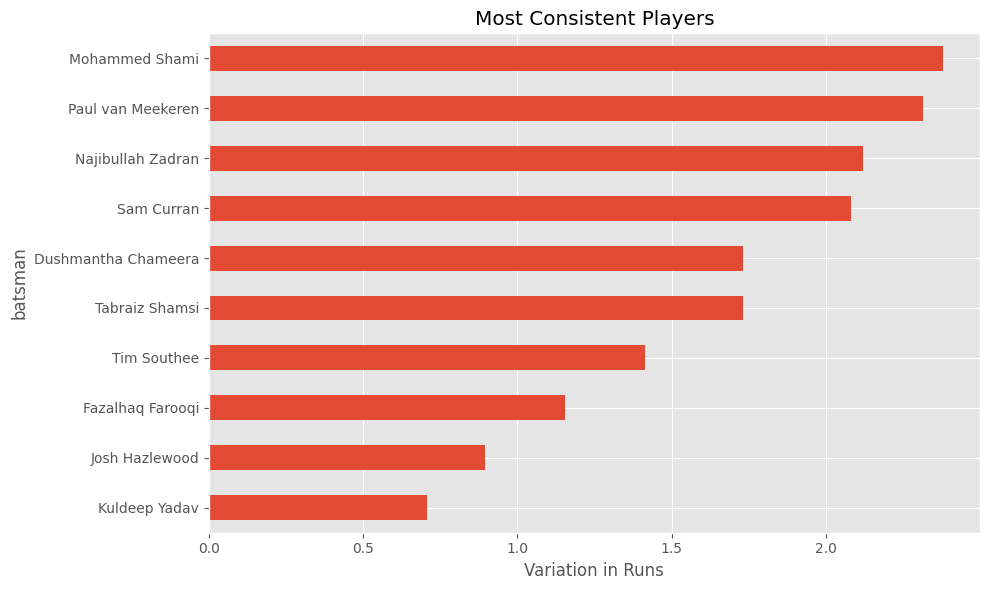

In [32]:
consistency = batting.groupby('batsman')['runs'].std().sort_values().head(10)

plt.figure(figsize=(10,6))
consistency.plot(kind='barh')

plt.title("Most Consistent Players")
plt.xlabel("Variation in Runs")

plt.tight_layout()
plt.show()

## 🚀 Clutch Performers

In [25]:
clutch = batting[batting['runs'] > 70]
clutch_players = clutch.groupby('batsman')['runs'].count().sort_values(ascending=False)
clutch_players.head(10)

batsman
Virat Kohli              6
Quinton de Kock          5
Shreyas Iyer             4
Rachin Ravindra          4
David Warner             3
Daryl Mitchell           3
Rohit Sharma             3
Rassie van der Dussen    3
Fakhar Zaman             2
Glenn Maxwell            2
Name: runs, dtype: int64

## 🔗 Correlation Analysis

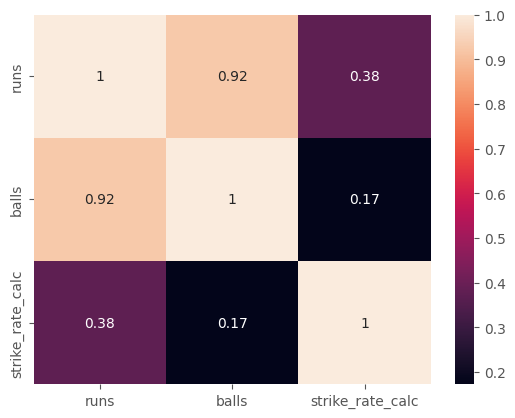

In [26]:
sns.heatmap(batting[['runs','balls','strike_rate_calc']].corr(), annot=True)
plt.show()

## 🧭 Final Insights

- Top-order batsmen dominate scoring → strong opening is critical  
- High strike rate players contribute more to match wins  
- Certain venues consistently produce high scores  
- All-rounders and clutch players influence match outcomes heavily  
- Teams with balanced batting + bowling win more matches  

## 🚀 Recommendations

- Focus on aggressive top order  
- Use low economy bowlers in middle overs  
- Venue-based strategy is essential  
- Identify and retain clutch players  
